In [1]:
import json
import re
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

colors = ['#4361ee', '#3a86ff', '#ff006e', '#fb5607', '#8338ec',
          '#06d6a0', '#118ab2', '#ffd166', '#ef476f', '#073b4c']

train_data = json.loads(Path('../data/processed/train_data.json').read_text(encoding='utf-8'))
print(f'Loaded {len(train_data)} training resumes')

Loaded 186 training resumes


In [2]:
entity_stats = {}

for item in train_data:
    text = item['text']
    for start, end, label in item['entities']:
        span_text = text[start:end].strip()

        if label not in entity_stats:
            entity_stats[label] = {
                'count': 0,
                'token_lengths': [],
                'has_digit': 0,
                'starts_uppercase': 0,
                'is_multi_token': 0,
                'examples': []
            }

        s = entity_stats[label]
        s['count'] += 1
        s['token_lengths'].append(len(span_text.split()))

        if re.search(r'\d', span_text):        s['has_digit'] += 1
        if span_text and span_text[0].isupper(): s['starts_uppercase'] += 1
        if len(span_text.split()) > 1:           s['is_multi_token'] += 1
        if len(s['examples']) < 3:               s['examples'].append(span_text[:40])

rows = []
for label, s in sorted(entity_stats.items()):
    n = s['count']
    rows.append({
        'Label':            label,
        'Count':            n,
        'Avg Tokens':       round(sum(s['token_lengths']) / n, 1),
        'Has Digit (%)':    round(s['has_digit']        / n * 100),
        'Starts Upper (%)': round(s['starts_uppercase'] / n * 100),
        'Multi-Token (%)':  round(s['is_multi_token']   / n * 100),
        'Example':          s['examples'][0] if s['examples'] else ''
    })

df = pd.DataFrame(rows).set_index('Label')
print('Surface features per entity type:')
df

Surface features per entity type:


,Count,Avg Tokens,Has Digit (%),Starts Upper (%),Multi-Token (%),Example
Label,,,,,,
COLLEGE_NAME,272,4.0,6,46,97,ovely Professional University
COMPANIES_WORKED_AT,603,1.7,1,69,50,Infosys limited
DEGREE,218,4.0,3,63,74,achelor Of Engineering in Mechanical Eng
DESIGNATION,454,2.7,2,80,90,DEVOPS ADMINISTRATOR
EMAIL_ADDRESS,212,1.3,100,3,29,indeed.com/r/Koushik-Katta/a6b1924485419
GRADUATION_YEAR,228,1.1,95,4,14,2014
LOCATION,361,1.1,1,81,6,Hyderabad
NAME,192,2.0,0,96,100,Koushik Katta
SKILLS,399,16.0,32,53,63,"Atlassian Tools: Jira, Confluence\nConfig"


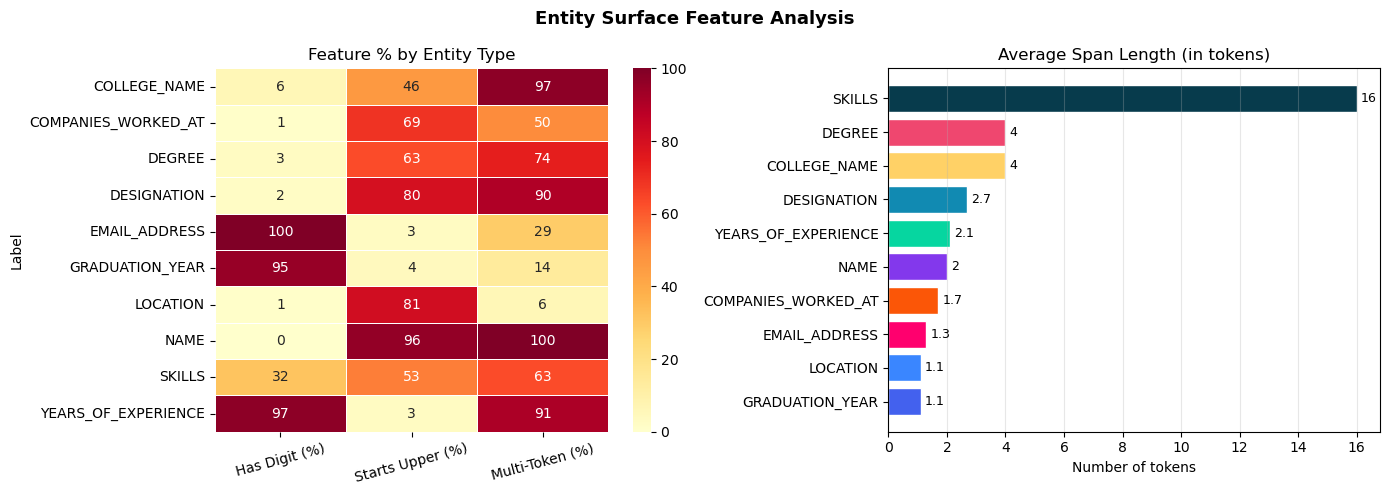

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Entity Surface Feature Analysis', fontweight='bold', fontsize=13)

feature_cols = ['Has Digit (%)', 'Starts Upper (%)', 'Multi-Token (%)']
sns.heatmap(
    df[feature_cols].astype(float),
    annot=True, fmt='.0f', cmap='YlOrRd',
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Feature % by Entity Type')
axes[0].tick_params(axis='x', rotation=15)

sorted_df = df.sort_values('Avg Tokens')
hb = axes[1].barh(sorted_df.index, sorted_df['Avg Tokens'],
                   color=colors[:len(sorted_df)], edgecolor='white')
axes[1].bar_label(hb, padding=3, fontsize=9)
axes[1].set_title('Average Span Length (in tokens)')
axes[1].set_xlabel('Number of tokens')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

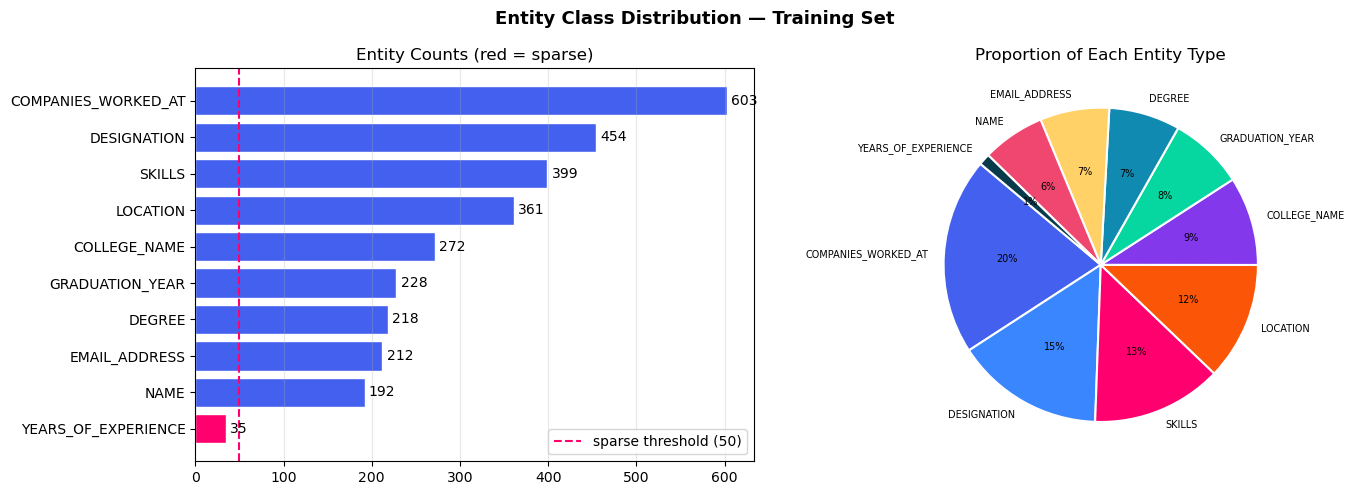

Warning — sparse labels (< 50 examples): ['YEARS_OF_EXPERIENCE']
These may have lower recall after fine-tuning


In [4]:
label_counts = Counter()
for item in train_data:
    for _, _, lbl in item['entities']:
        label_counts[lbl] += 1

labels_sorted = [l for l, _ in label_counts.most_common()]
counts_sorted = [label_counts[l] for l in labels_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Entity Class Distribution — Training Set', fontweight='bold', fontsize=13)

bar_colors = [colors[2] if c < 50 else colors[0] for c in counts_sorted]
hb2 = axes[0].barh(labels_sorted, counts_sorted, color=bar_colors, edgecolor='white')
axes[0].bar_label(hb2, padding=3)
axes[0].invert_yaxis()
axes[0].axvline(50, color=colors[2], linestyle='--', linewidth=1.5, label='sparse threshold (50)')
axes[0].set_title('Entity Counts (red = sparse)')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='x')

axes[1].pie(
    counts_sorted,
    labels=labels_sorted,
    colors=colors[:len(labels_sorted)],
    autopct='%1.0f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in axes[1].texts:
    text.set_fontsize(7)
axes[1].set_title('Proportion of Each Entity Type')

plt.tight_layout()
plt.show()

sparse = [l for l, c in label_counts.items() if c < 50]
if sparse:
    print(f'Warning — sparse labels (< 50 examples): {sparse}')
    print('These may have lower recall after fine-tuning')

C:\Users\Amira Elsayed\AppData\Local\Temp\ipykernel_33364\65571916.py:43: UserWarning: Glyph 128274 (\N{LOCK}) missing from current font.
  plt.tight_layout()
C:\Users\Amira Elsayed\AppData\Local\Temp\ipykernel_33364\65571916.py:43: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\Amira Elsayed\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128274 (\N{LOCK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Amira Elsayed\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


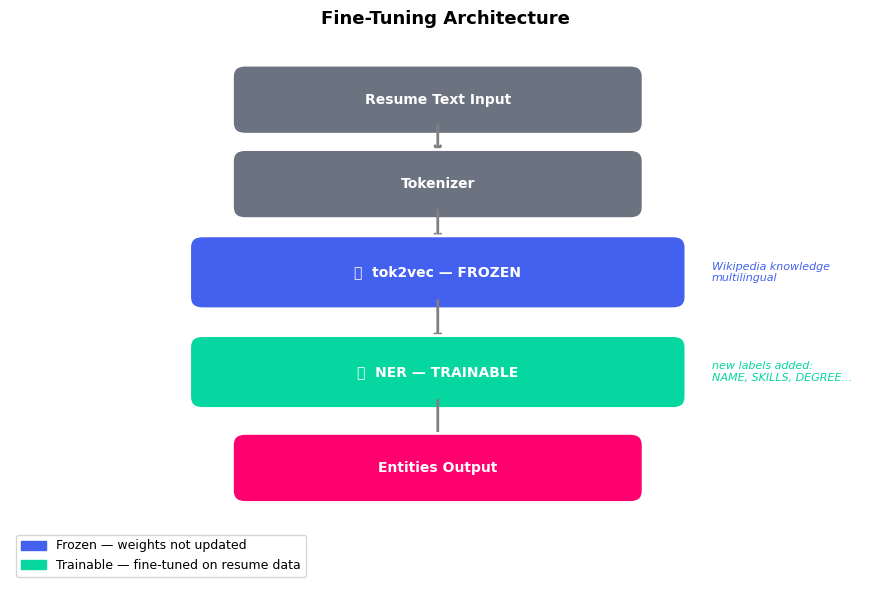

In [5]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')
fig.suptitle('Fine-Tuning Architecture', fontweight='bold', fontsize=13)

def draw_box(ax, x, y, width, height, text, color, text_color='white'):
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle='round,pad=0.15', facecolor=color,
        edgecolor='white', linewidth=2, zorder=3
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            color=text_color, fontsize=10, fontweight='bold', zorder=4)

def draw_arrow(ax, y_start, y_end):
    ax.annotate('', xy=(5, y_end), xytext=(5, y_start),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

draw_box(ax, 5, 6.3, 4.5, 0.6,  'Resume Text Input',    '#6b7280')
draw_arrow(ax, 6.0, 5.55)
draw_box(ax, 5, 5.2, 4.5, 0.6,  'Tokenizer',            '#6b7280')
draw_arrow(ax, 4.9, 4.4)
draw_box(ax, 5, 4.05, 5.5, 0.65,'🔒  tok2vec — FROZEN', '#4361ee')
ax.text(8.2, 4.05, 'Wikipedia knowledge\nmultilingual',
        fontsize=8, color='#4361ee', style='italic', va='center')
draw_arrow(ax, 3.72, 3.1)
draw_box(ax, 5, 2.75, 5.5, 0.65,'🎯  NER — TRAINABLE',  '#06d6a0')
ax.text(8.2, 2.75, 'new labels added:\nNAME, SKILLS, DEGREE...',
        fontsize=8, color='#06d6a0', style='italic', va='center')
draw_arrow(ax, 2.42, 1.8)
draw_box(ax, 5, 1.5, 4.5, 0.6,  'Entities Output',      '#ff006e')

legend = [
    mpatches.Patch(color='#4361ee', label='Frozen — weights not updated'),
    mpatches.Patch(color='#06d6a0', label='Trainable — fine-tuned on resume data')
]
ax.legend(handles=legend, loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()